In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
from scipy.stats import ttest_ind,chi2_contingency
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.utils import resample
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, make_scorer
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import pairwise_distances
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('mcdonalds.csv')
df.head()

,yummy,convenient,spicy,fattening,greasy,fast,cheap,tasty,expensive,healthy,disgusting,Like,Age,VisitFrequency,Gender
0,No,Yes,No,Yes,No,Yes,Yes,No,Yes,No,No,-3,61,Every three months,Female
1,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,+2,51,Every three months,Female
2,No,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,No,+1,62,Every three months,Female
3,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,No,No,Yes,+4,69,Once a week,Female
4,No,Yes,No,Yes,Yes,Yes,Yes,No,No,Yes,No,+2,49,Once a month,Male


In [3]:
# Check for null values
df.isnull().sum()

,0
yummy,0
convenient,0
spicy,0
fattening,0
greasy,0
fast,0
cheap,0
tasty,0
expensive,0
healthy,0


In [4]:
# Check for duplicates and drop them
df.drop_duplicates(inplace=True)

In [5]:
# Basic stats
df.describe()

,Age
count,1431.000000
mean,44.656184
std,14.199400
min,18.000000
25%,33.000000
50%,45.000000
75%,57.000000
max,71.000000


In [6]:
df.shape

(1431, 15)

In [7]:
binary_cols = df.columns[0:11]
binary_cols

Index(['yummy', 'convenient', 'spicy', 'fattening', 'greasy', 'fast', 'cheap',
       'tasty', 'expensive', 'healthy', 'disgusting'],
      dtype='object')

In [8]:
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [9]:
# Sentiment Score (Like +5 means I love it, -5 means I hate it)
def sentiment_score(x):
    if isinstance(x, str):
        if 'love' in x.lower():
            return 5
        elif 'hate' in x.lower():
            return -5
        else:
            return int(x)
    return x

df['Like'] = df['Like'].apply(sentiment_score)
df['Like'].value_counts().sort_index()

,count
Like,
-5,150
-4,70
-3,73
-2,59
-1,58
0,168
1,152
2,180
3,225


In [10]:
# Create a scatter plot of 'expensive' vs 'tasty'
chart = alt.Chart(df).mark_point().encode(
    x='expensive:Q',  # Encode 'expensive' on the x-axis as a quantitative variable
    y='tasty:Q'       # Encode 'tasty' on the y-axis as a quantitative variable
).properties(
    title='Expensive vs Tasty'
)
# Display the chart
chart

alt.Chart(...)

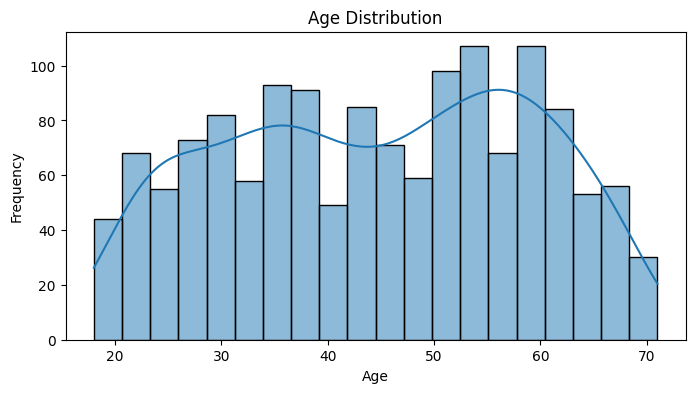

In [11]:
# Plotting distribution of Age
plt.figure(figsize=(8, 4))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

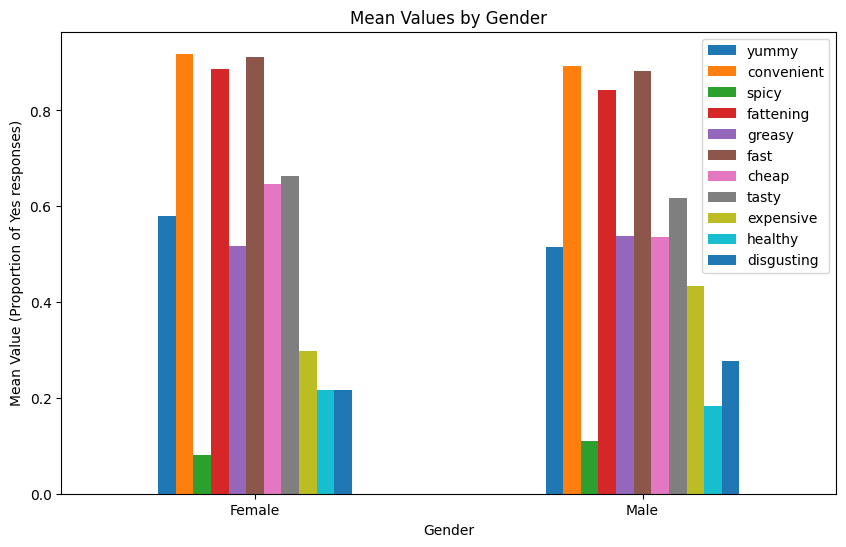

In [12]:
# Groupby gender and plot
binary_cols_with_gender = binary_cols.tolist() + ['Gender']
df[binary_cols_with_gender].groupby(['Gender']).mean().plot(kind='bar', figsize=(10, 6))

plt.title('Mean Values by Gender')
plt.xlabel('Gender')
plt.ylabel('Mean Value (Proportion of Yes responses)')
plt.xticks(rotation=0)
plt.show()

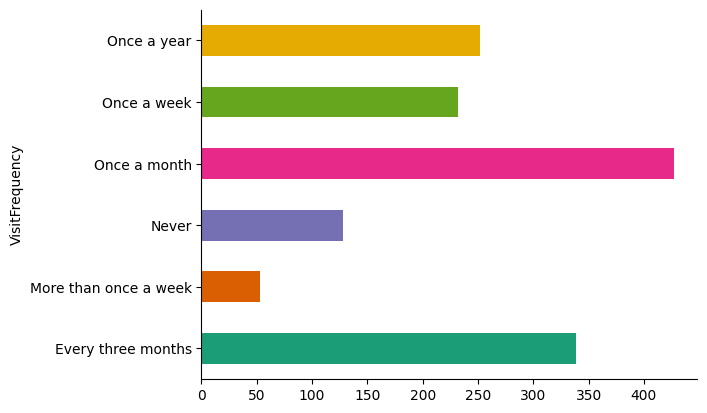

In [13]:
df.groupby('VisitFrequency').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

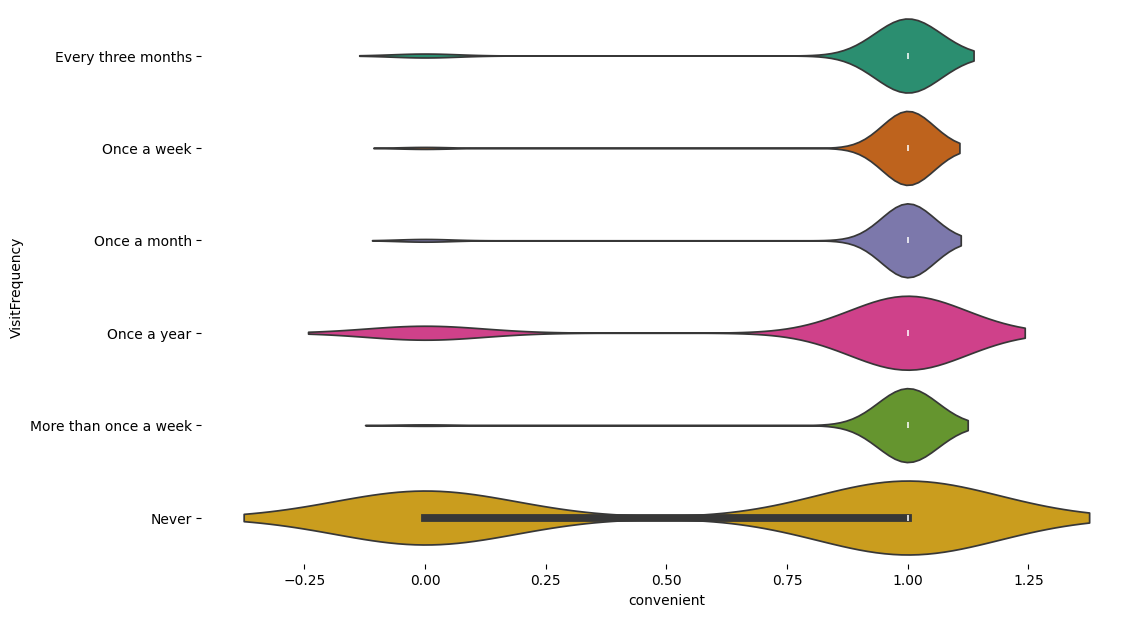

In [14]:
figsize = (12, 1.2 * len(df['VisitFrequency'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(df, x='convenient', y='VisitFrequency', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

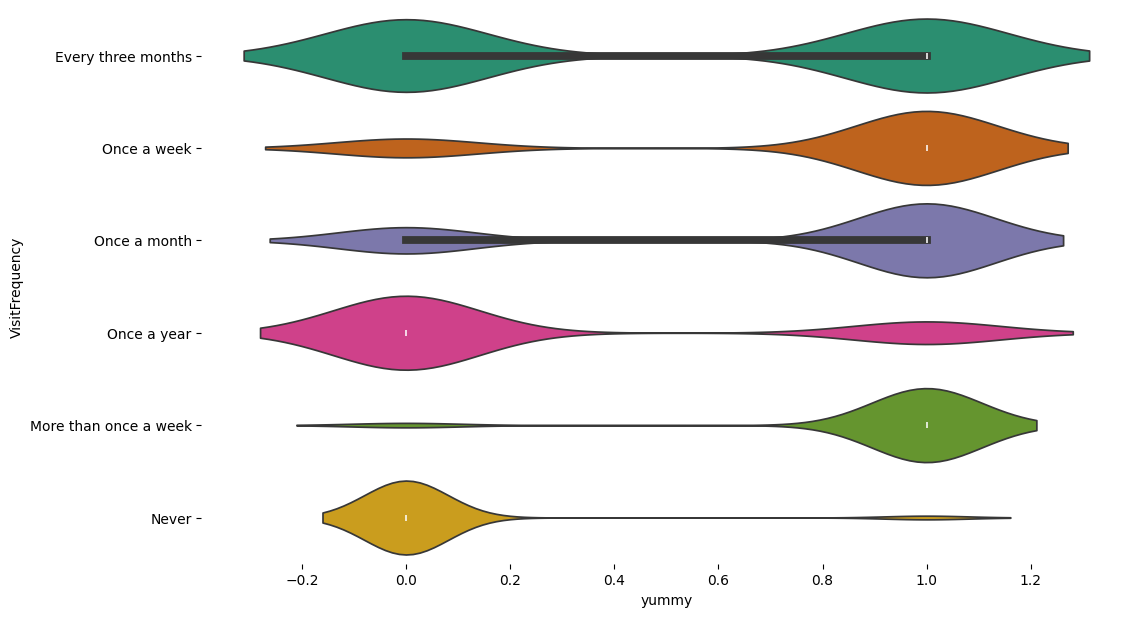

In [15]:
figsize = (12, 1.2 * len(df['VisitFrequency'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(df, x='yummy', y='VisitFrequency', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

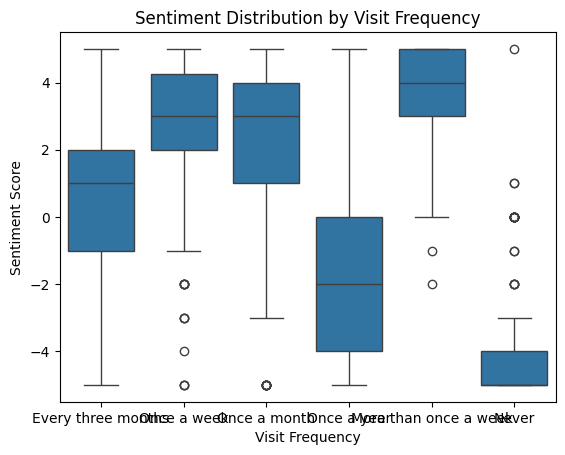

In [16]:
# Sentiment distribution by visit frequency
sns.boxplot(x='VisitFrequency', y='Like', data=df)
plt.title('Sentiment Distribution by Visit Frequency')
plt.xlabel('Visit Frequency')
plt.ylabel('Sentiment Score')
plt.show()

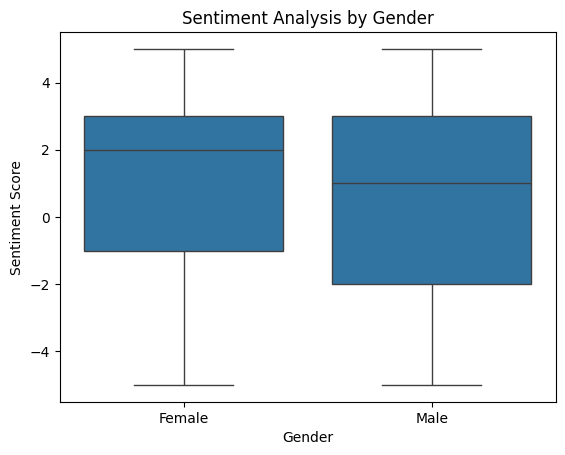

In [17]:
# Sentiment analysis by gender
sns.boxplot(x='Gender', y='Like', data=df)
plt.title('Sentiment Analysis by Gender')
plt.xlabel('Gender')
plt.ylabel('Sentiment Score')
plt.show()

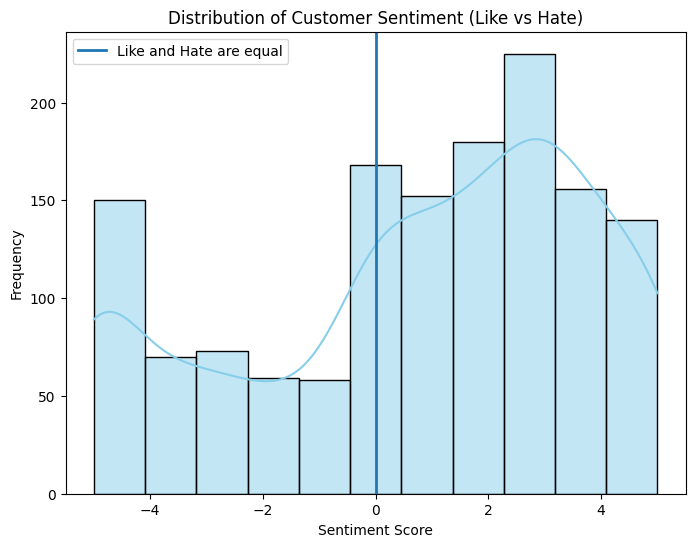

In [18]:
# Distribution of customers like vs hate
plt.figure(figsize=(8, 6))
sns.histplot(df['Like'], bins=11, kde=True, color='skyblue', edgecolor='black')
plt.axvline(x=0, linewidth=2, label='Like and Hate are equal')
plt.title('Distribution of Customer Sentiment (Like vs Hate)')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [19]:
# Age bins
bins = [0, 20, 30, 40, 50, 60, 70, df['Age'].max()]
labels = ['<20', '20-30', '30-40', '40-50', '50-60', '60-70', '70+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
df['AgeGroup'].value_counts().sort_index()

,count
AgeGroup,
<20,25
20-30,243
30-40,296
40-50,264
50-60,342
60-70,245
70+,15


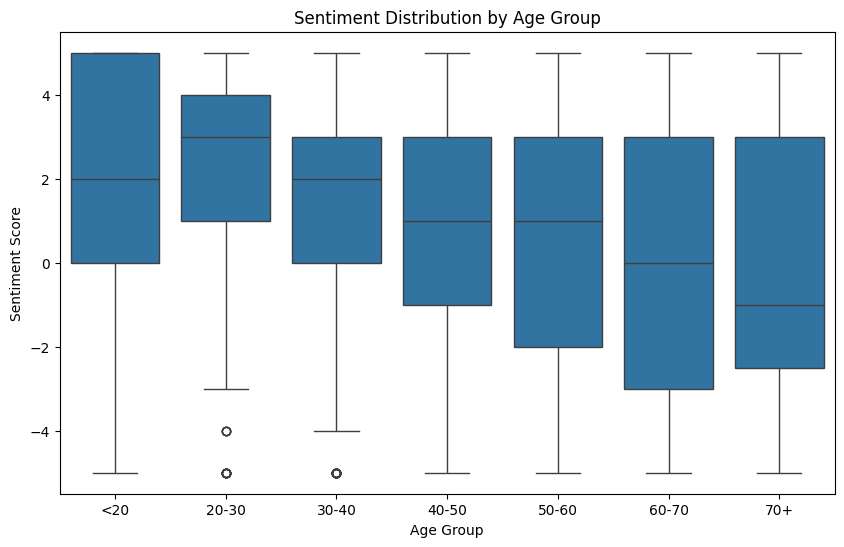

In [20]:
# Sentiment distribution by age group
plt.figure(figsize=(10, 6))
sns.boxplot(x='AgeGroup', y='Like', data=df, order=labels)
plt.title('Sentiment Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Sentiment Score')
plt.show()

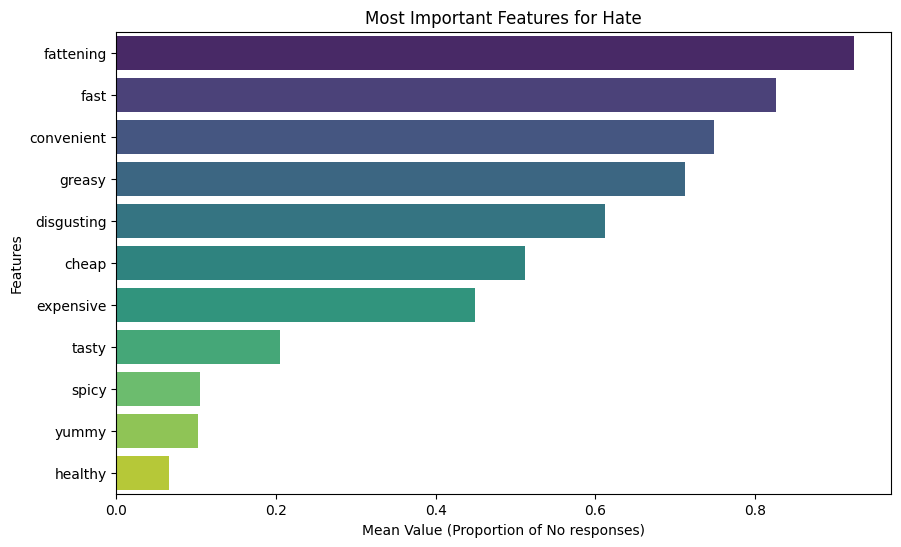

In [21]:
# Important features for hate
df_hate = df[df.Like<0]
important_features_hate = df.loc[df.Like<0][binary_cols].mean().sort_values(ascending=False)

#Plot important_features_hate
plt.figure(figsize=(10, 6))
sns.barplot(x=important_features_hate.values, y=important_features_hate.index, palette='viridis')
plt.title('Most Important Features for Hate')
plt.xlabel('Mean Value (Proportion of No responses)')
plt.ylabel('Features')
plt.show()

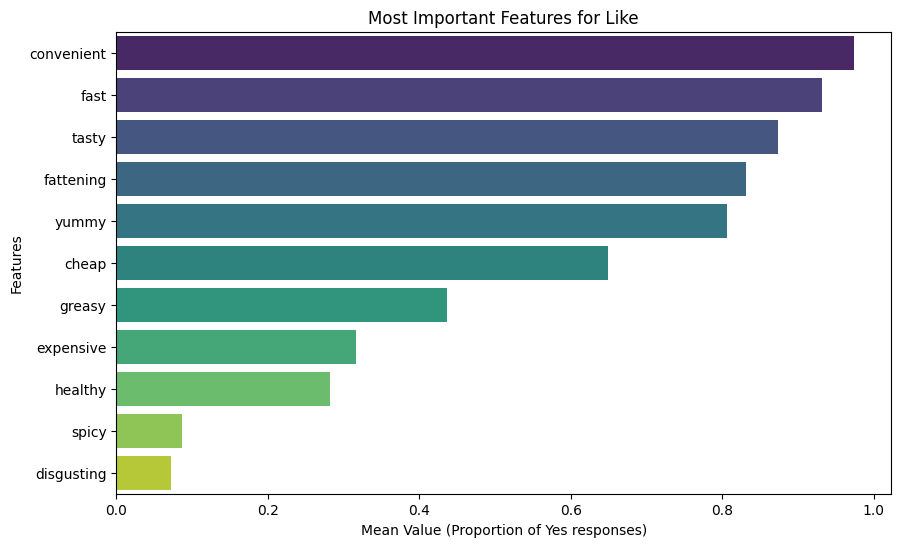

In [22]:
# Important features for like
df_like = df[df.Like>0]
important_features_like = df.loc[df.Like>0][binary_cols].mean().sort_values(ascending=False)

#Plot important_features_hate
plt.figure(figsize=(10, 6))
sns.barplot(x=important_features_like.values, y=important_features_like.index, palette='viridis')
plt.title('Most Important Features for Like')
plt.xlabel('Mean Value (Proportion of Yes responses)')
plt.ylabel('Features')
plt.show()

In [23]:
# Statistical test for sentiment
t_stat, p_value = ttest_ind(df_like['Like'], df_hate['Like'])
print(f'T-statistic: {t_stat}, P-value: {p_value}')

T-statistic: 77.925417791589, P-value: 0.0


In [24]:
# chi squared test
contingency_table = pd.crosstab(df['Gender'], df['Like'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f'Chi-squared statistic: {chi2}, P-value: {p}')

Chi-squared statistic: 11.40662663409069, P-value: 0.3267274331544179


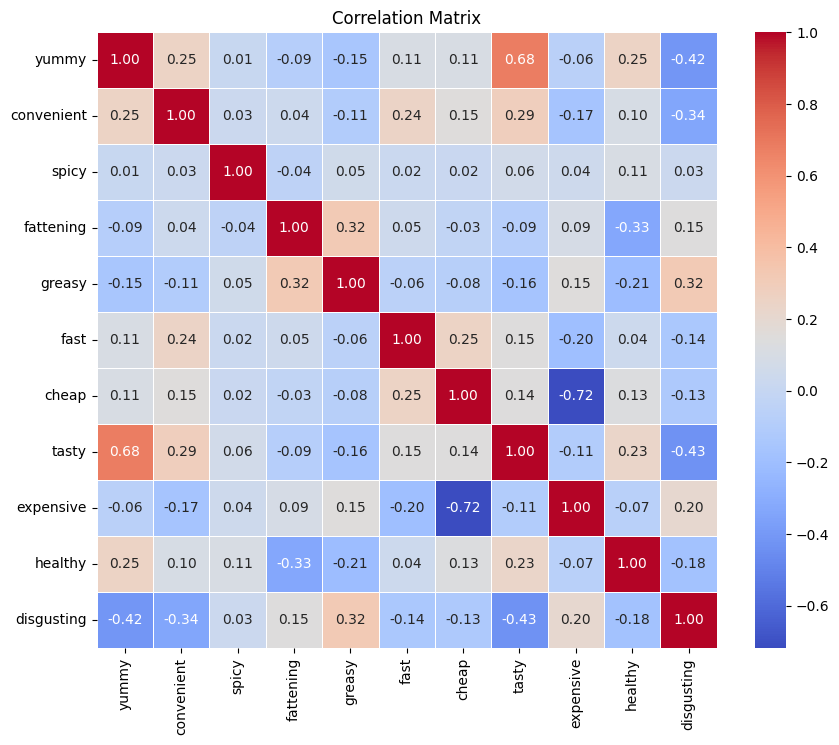

In [25]:
# Correlation matrix
corr_matrix = df[binary_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix')
plt.show()

In [26]:
from sklearn.decomposition import PCA
pca = PCA()
pca_df = pca.fit_transform(df[binary_cols])

print("PCA Summary:\n", pd.DataFrame({
    'Standard deviation': np.sqrt(pca.explained_variance_),
    'Proportion of Variance': pca.explained_variance_ratio_,
    'Cumulative Proportion': np.cumsum(pca.explained_variance_ratio_)
}).round(4))

PCA Summary:
     Standard deviation  Proportion of Variance  Cumulative Proportion
0               0.7580                  0.2990                 0.2990
1               0.6067                  0.1916                 0.4906
2               0.5049                  0.1327                 0.6232
3               0.3991                  0.0829                 0.7061
4               0.3387                  0.0597                 0.7658
5               0.3121                  0.0507                 0.8165
6               0.2918                  0.0443                 0.8608
7               0.2767                  0.0399                 0.9007
8               0.2672                  0.0372                 0.9378
9               0.2503                  0.0326                 0.9704
10              0.2383                  0.0296                 1.0000


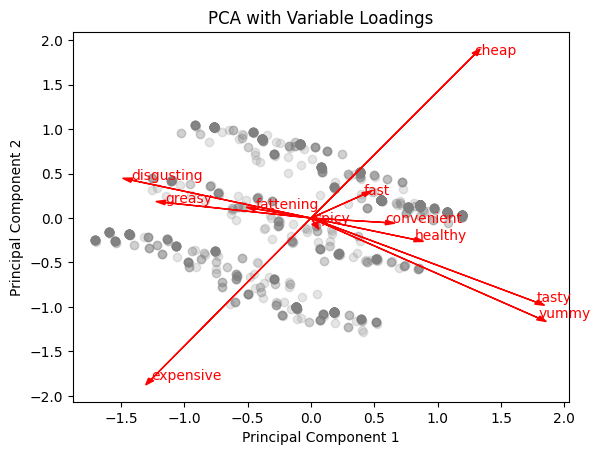

In [27]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
pca_proj = pca.transform(df[binary_cols])
plt.scatter(pca_proj[:, 0], pca_proj[:, 1], c='grey', alpha=0.2)
for i, col in enumerate(df[binary_cols]):
    plt.arrow(0, 0, loadings[i, 0]*5, loadings[i, 1]*5, color='red', head_width=0.05)
    plt.text(loadings[i, 0]*5, loadings[i, 1]*5, col, color='red')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA with Variable Loadings')
plt.show()

# Clustering Using KMeans

In [28]:
# Use binary_cols and like column
# Redefine binary_cols to ensure it contains the original column names
binary_cols = df.columns[0:11].tolist()

X = df[binary_cols + ['Like']]
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

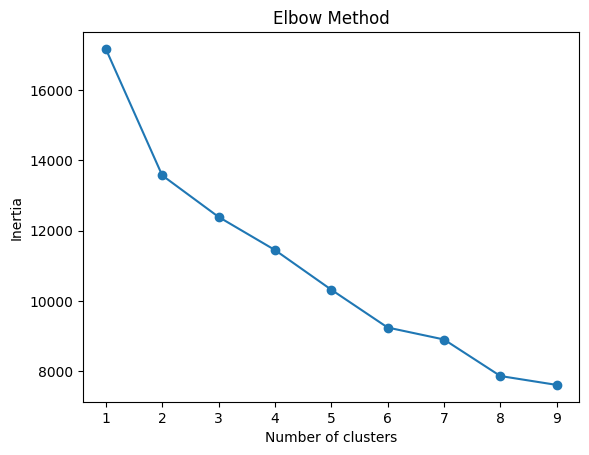

In [29]:
inertia = []
for k in range(1,10):
  km = KMeans(n_clusters=k, random_state=42)
  km.fit(scaled_data)
  inertia.append(km.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

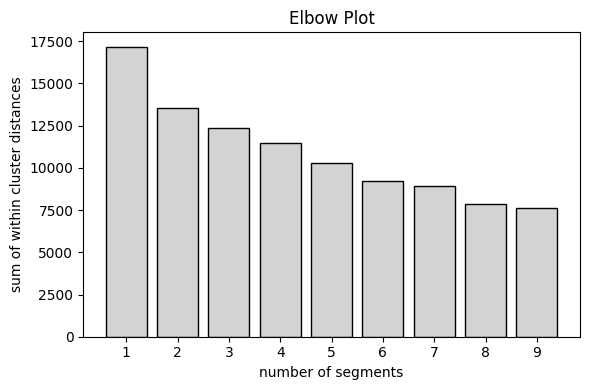

In [30]:
# Plot Elbow Plot (sum of within-cluster distances)
k_range = range(1,10)
plt.figure(figsize=(6, 4))
plt.bar(k_range, inertia, color='lightgrey', edgecolor='black')
plt.xlabel("number of segments")
plt.ylabel("sum of within cluster distances")
plt.title("Elbow Plot")
plt.xticks(k_range)
plt.tight_layout()
plt.show()

In [31]:
km = KMeans(n_clusters=4,random_state=42)
df['Cluster'] = km.fit_predict(scaled_data)
df.head()

,yummy,convenient,spicy,fattening,greasy,fast,cheap,tasty,expensive,healthy,disgusting,Like,Age,VisitFrequency,Gender,AgeGroup,Cluster
0,0,1,0,1,0,1,1,0,1,0,0,-3,61,Every three months,Female,60-70,0
1,1,1,0,1,1,1,1,1,1,0,0,2,51,Every three months,Female,50-60,1
2,0,1,1,1,1,1,0,1,1,1,0,1,62,Every three months,Female,60-70,0
3,1,1,0,1,1,1,1,1,0,0,1,4,69,Once a week,Female,60-70,1
4,0,1,0,1,1,1,1,0,0,1,0,2,49,Once a month,Male,40-50,0


In [32]:
df['Cluster'].unique()

array([0, 1, 2, 3], dtype=int32)

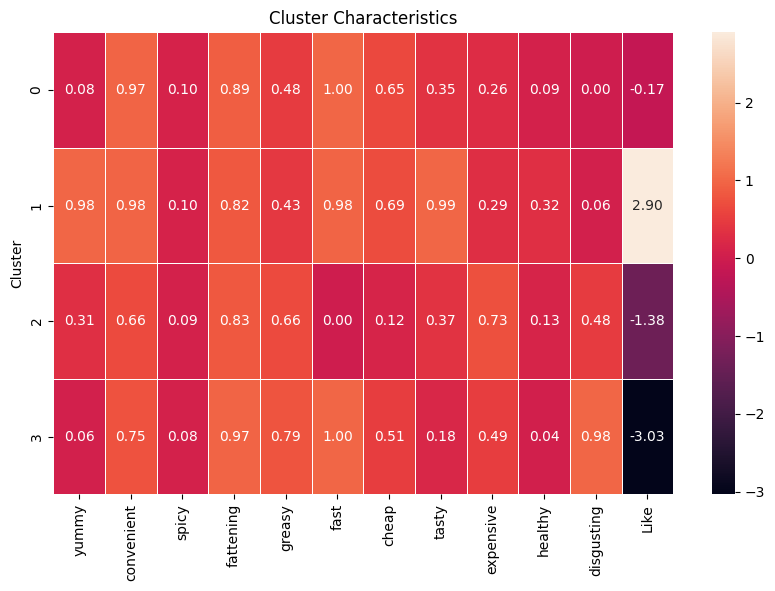

In [33]:
cluster_type = df.groupby('Cluster')[binary_cols + ['Like']].mean()
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_type, annot=True, fmt='.2f', linewidths=.5)
plt.title('Cluster Characteristics')
plt.show()

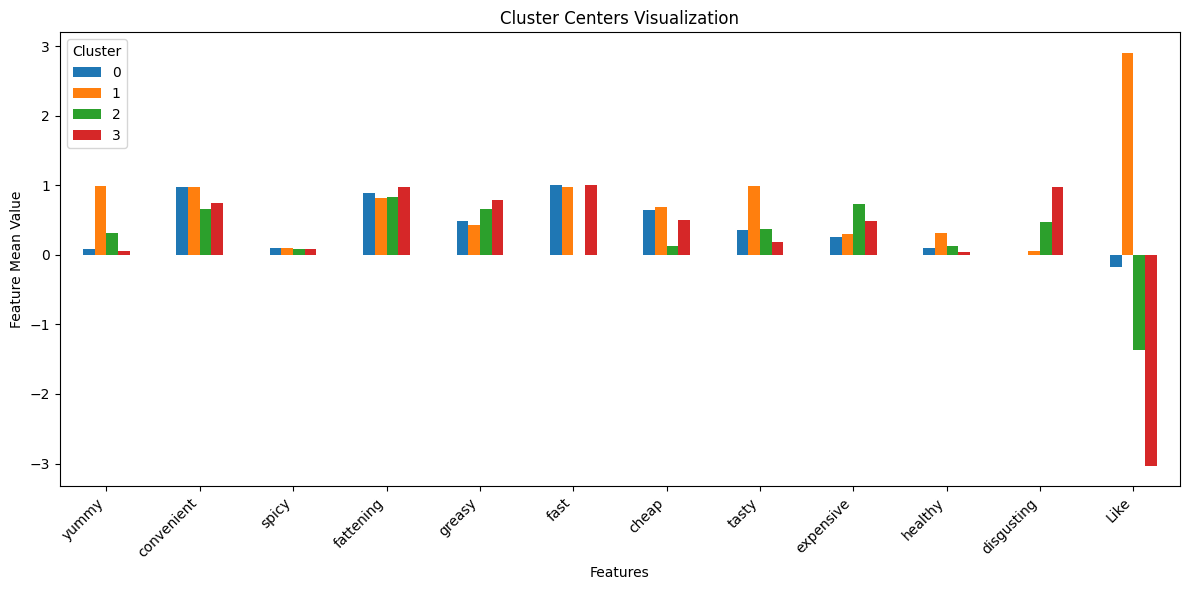

In [34]:
# Get cluster centers
centers = km.cluster_centers_

# Inverse transform centers to original scale
centers_orig = scaler.inverse_transform(centers)
features = binary_cols + ['Like']

# Create DataFrame for centers
centers_df = pd.DataFrame(centers_orig, columns=features)

# Plotting cluster centers using bar plot
fig, ax = plt.subplots(figsize=(12, 6))
centers_df.T.plot(kind='bar', ax=ax)
plt.title('Cluster Centers Visualization')
plt.ylabel('Feature Mean Value')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

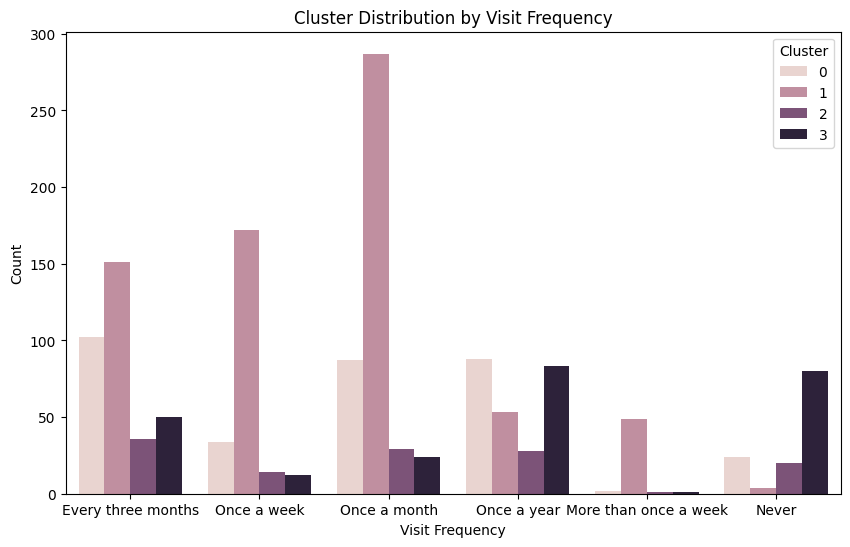

In [35]:
# Cluster distribution by visit frequency
plt.figure(figsize=(10, 6))
sns.countplot(x='VisitFrequency', hue='Cluster', data=df)
plt.title('Cluster Distribution by Visit Frequency')
plt.xlabel('Visit Frequency')
plt.ylabel('Count')
plt.legend(title='Cluster')
plt.show()

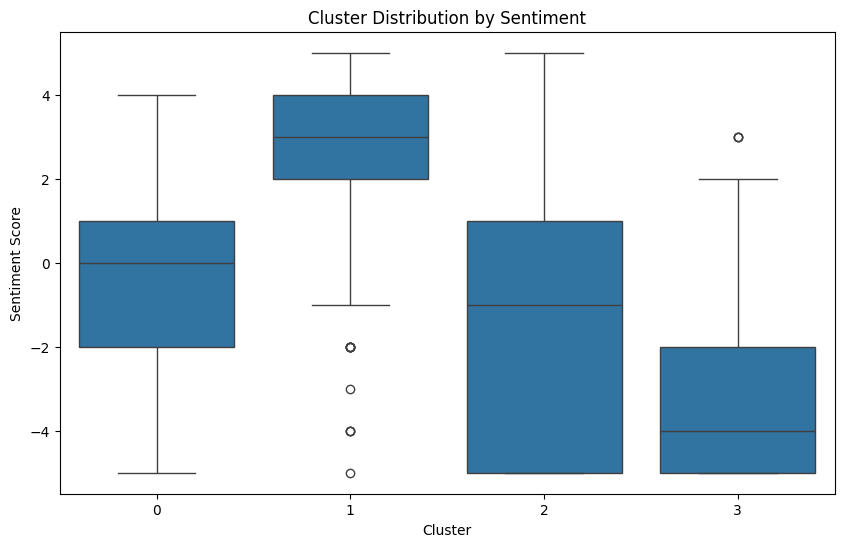

In [36]:
# Cluster ditribution by sentiment
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='Like', data=df)
plt.title('Cluster Distribution by Sentiment')
plt.xlabel('Cluster')
plt.ylabel('Sentiment Score')
plt.show()

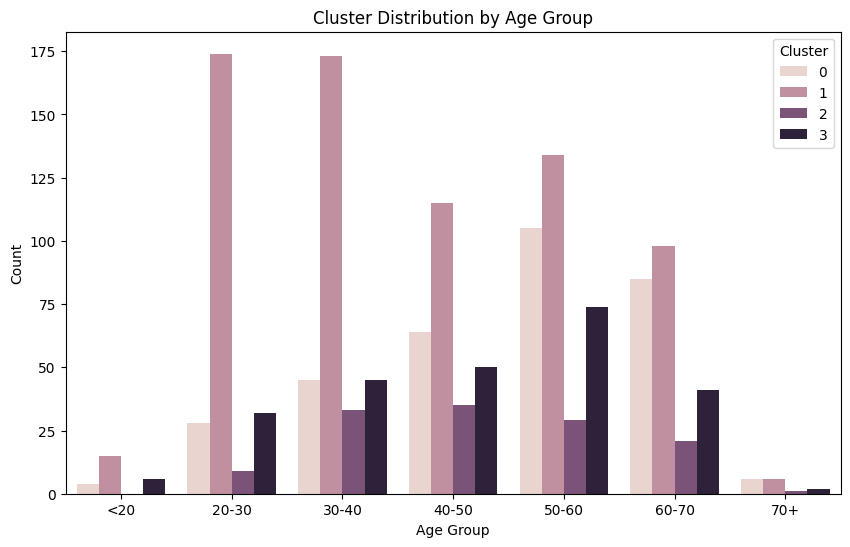

In [37]:
# Cluster ditribution by age group
plt.figure(figsize=(10, 6))
sns.countplot(x='AgeGroup', hue='Cluster', data=df)
plt.title('Cluster Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Cluster')
plt.show()

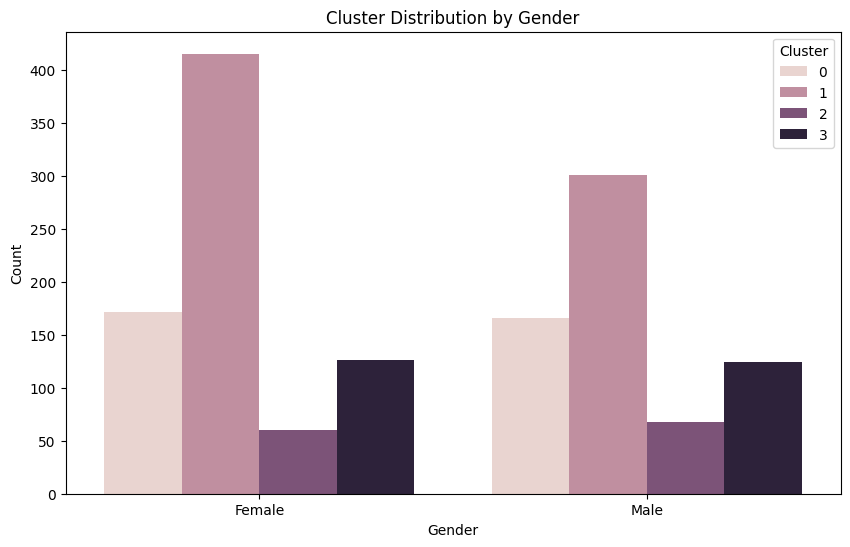

In [38]:
# Cluster distribution by gender
plt.figure(figsize=(10, 6))
sns.countplot(x='Gender', hue='Cluster', data=df)
plt.title('Cluster Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Cluster')
plt.show()

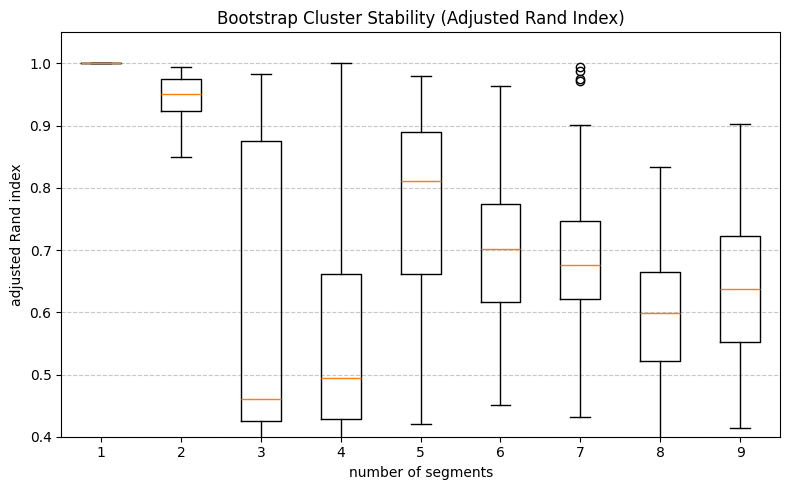

In [39]:
# Bootstrap stability - adjusted Rand index (ARI)
ari_scores = {k: [] for k in range(1,10)}

# Define the number of bootstrap repetitions
n_boot = 100  # You can adjust this number as needed

# Define the number of initializations for KMeans
n_rep = 10 # Or whatever value you used for the initial KMeans fit

# Store the original cluster assignments for each k
original_clusters = {}
for k in range(1, 10):
    km_orig = KMeans(n_clusters=k, n_init=n_rep, random_state=1234).fit(scaled_data)
    original_clusters[k] = km_orig.labels_

# Define min_k and max_k for plotting
min_k = 1
max_k = 9

for k in range(min_k, max_k + 1):
    orig_labels = original_clusters[k]

    for _ in range(n_boot):
        # Use .iloc to index the scaled_data array if it's a pandas DataFrame
        # If scaled_data is a numpy array, use standard numpy indexing: scaled_data[indices]
        indices = resample(np.arange(scaled_data.shape[0]), replace=True)
        # Check if scaled_data is a pandas DataFrame or numpy array
        if isinstance(scaled_data, pd.DataFrame):
            boot_data = scaled_data.iloc[indices]
        else: # Assume it's a numpy array
             boot_data = scaled_data[indices]


        # Fit KMeans to bootstrap sample once here
        km_boot = KMeans(n_clusters=k, n_init=n_rep, random_state=1234).fit(boot_data)
        boot_labels = km_boot.labels_

        # ARI between original labels of bootstrap indices and bootstrap clustering
        # Ensure orig_labels is indexed correctly for the bootstrap sample
        ari = adjusted_rand_score(orig_labels[indices], boot_labels)
        ari_scores[k].append(ari)

# Plot Bootstrap Cluster Stability (ARI)
plt.figure(figsize=(8, 5))
# Ensure the range for plotting matches the range of k values for which you calculated ARI
data_to_plot = [ari_scores[k] for k in range(min_k, max_k + 1)]
plt.boxplot(data_to_plot, positions=range(min_k, max_k + 1))
plt.xlabel("number of segments")
plt.ylabel("adjusted Rand index")
plt.title("Bootstrap Cluster Stability (Adjusted Rand Index)")
plt.xticks(range(min_k, max_k + 1))
plt.ylim(0.4, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

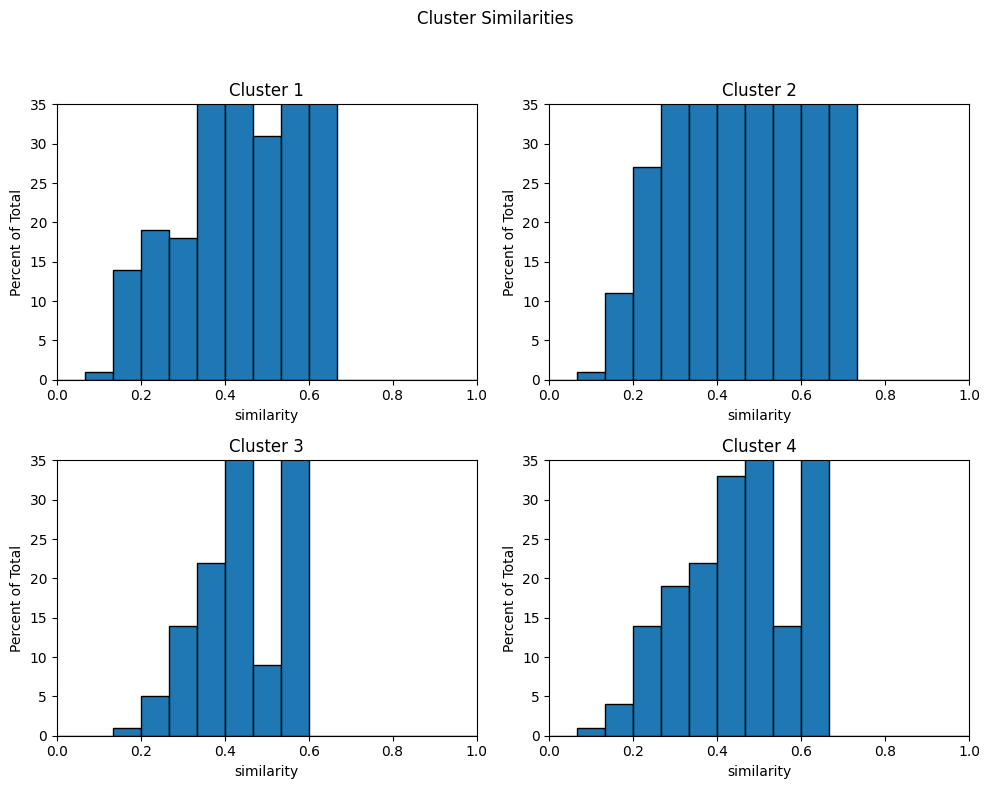

In [40]:
labels = km.labels_
centers = km.cluster_centers_

# Step 2: Compute distances from each point to its assigned center
distances = pairwise_distances(scaled_data, centers)
assigned_distances = distances[np.arange(len(scaled_data)), labels]
max_distances = distances.max(axis=1)

# Step 3: Convert distances to similarities (scaled to 0–1)
similarities = 1 - (assigned_distances / max_distances)

# Step 4: Plot histograms of similarity per cluster
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle('Cluster Similarities')

for cluster in range(4):
    ax = axes[cluster // 2, cluster % 2]
    sim_values = similarities[labels == cluster]

    ax.hist(sim_values, bins=15, range=(0, 1), edgecolor='black')
    ax.set_title(f"Cluster {cluster + 1}")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 35)
    ax.set_xlabel("similarity")
    ax.set_ylabel("Percent of Total")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

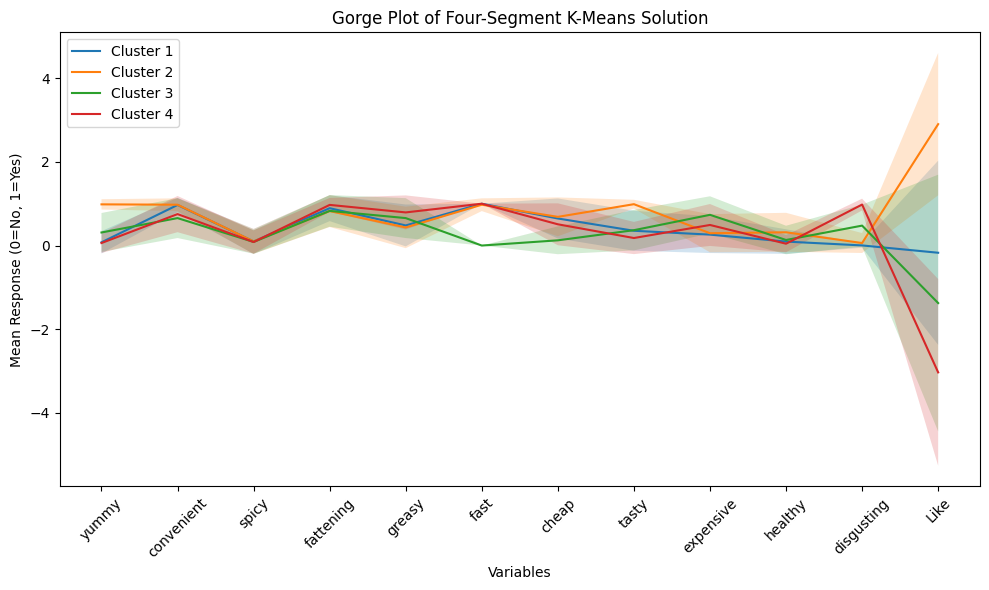

In [41]:
plt.figure(figsize=(10, 6))
for i in range(4):
    cluster_data = X[km.labels_ == i]
    plt.plot(cluster_data.mean(axis=0), label=f'Cluster {i+1}')
    plt.fill_between(range(len(cluster_data.mean(axis=0))),
                     cluster_data.mean(axis=0) - cluster_data.std(axis=0),
                     cluster_data.mean(axis=0) + cluster_data.std(axis=0),
                     alpha=0.2)

plt.xticks(range(len(X.columns)), X.columns, rotation=45)
plt.xlabel('Variables')
plt.ylabel('Mean Response (0=No, 1=Yes)')
plt.title('Gorge Plot of Four-Segment K-Means Solution')
plt.legend()
plt.tight_layout()
plt.show()

# Regression Models

In [42]:
visit_map = {"Never":0, "Once a year":1, "Every three months":2, "Once a month":3, "Once a week":4, "More than once a week":5}
df['VisitFrequency_enc'] = df['VisitFrequency'].map(visit_map)
df['Gender_enc'] = df['Gender'].map({'Male': 0, 'Female': 1})

features = binary_cols + ['Age', 'VisitFrequency_enc', 'Gender_enc']

y = df['Like']
X = df[features]

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Fit the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [43]:
print('Linear Regression:')
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'Mean Absolute Error: {mae}')
print(f'R-squared: {r2}')

Linear Regression:
Mean Squared Error: 3.088297989047948
Root Mean Squared Error: 1.757355396340748
Mean Absolute Error: 1.3544223286362291
R-squared: 0.692174746835116


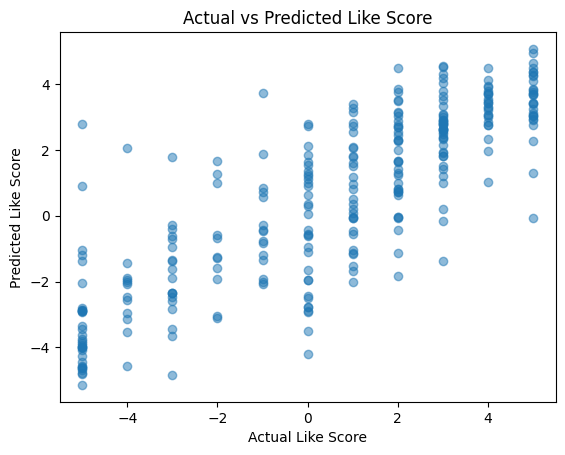

In [44]:
# Actual vs. Predicted
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Like Score")
plt.ylabel("Predicted Like Score")
plt.title("Actual vs Predicted Like Score")
plt.show()

In [45]:
# Important features of linear regression
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
coefficients.sort_values(by='Coefficient', ascending=False, inplace=True)
coefficients

,Coefficient
VisitFrequency_enc,1.041937
yummy,0.819856
tasty,0.586254
convenient,0.176255
healthy,0.165501
fast,0.152539
Gender_enc,0.028955
spicy,-0.036707
cheap,-0.048194
expensive,-0.100077


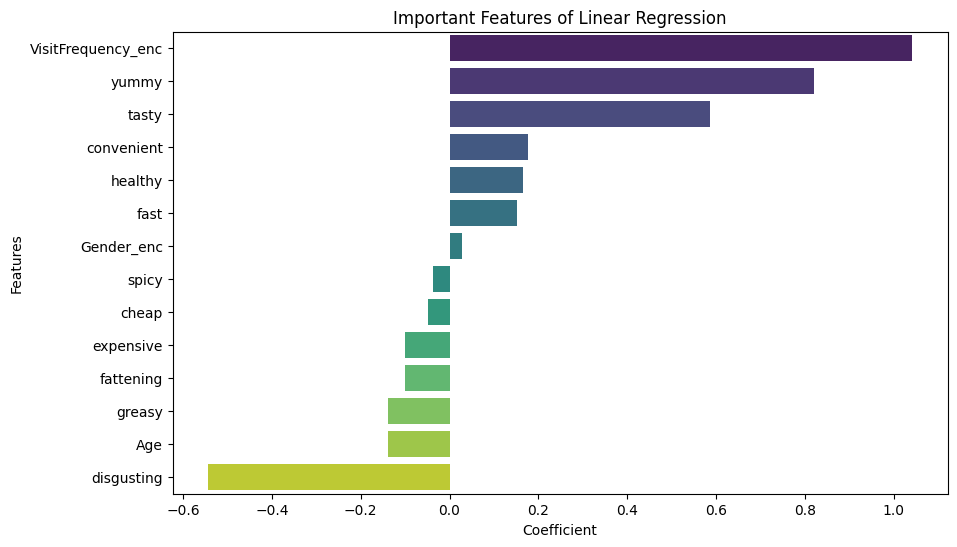

In [46]:
# Plot the important features
plt.figure(figsize=(10, 6))
sns.barplot(x=coefficients['Coefficient'], y=coefficients.index, palette='viridis')
plt.title('Important Features of Linear Regression')
plt.xlabel('Coefficient')
plt.ylabel('Features')
plt.show()

In [47]:
# Try cross-validation for better r2 score
# Perform 5-fold cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print("Cross-validated R2 scores:", cv_scores)
print("Mean R2 score:", np.mean(cv_scores))

Cross-validated R2 scores: [0.6889507  0.689336   0.68222004 0.68434372 0.73168095]
Mean R2 score: 0.6953062812114716


No much change

In [72]:
# Define models
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42)
}

# Define a custom RMSE scorer
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

scoring = {
    'r2': 'r2',
    'mse': make_scorer(mean_squared_error, greater_is_better=False),
    'mae': make_scorer(mean_absolute_error, greater_is_better=False),
    'rmse': make_scorer(rmse, greater_is_better=False)
}

results = []

for name, model in models.items():
    X_input = X_scaled if name in ['Ridge', 'Lasso', 'LinearRegression'] else X
    scores = cross_validate(model, X_input, y, cv=5, scoring=scoring)
    results.append({
        'Model': name,
        'R2': np.mean(scores['test_r2']),
        'MSE': -np.mean(scores['test_mse']),   # Negate because sklearn uses negative MSE for scoring
        'MAE': -np.mean(scores['test_mae']),   # Negate for same reason
        'RMSE': -np.mean(scores['test_rmse'])  # Negate for same reason
    })

results_df = pd.DataFrame(results)
results_df

,Model,R2,MSE,MAE,RMSE
0,LinearRegression,0.695306,2.939731,1.338628,1.713853
1,Ridge,0.695317,2.939622,1.338690,1.713822
2,Lasso,0.692405,2.970534,1.360102,1.722666
3,RandomForest,0.629005,3.570995,1.462712,1.889120


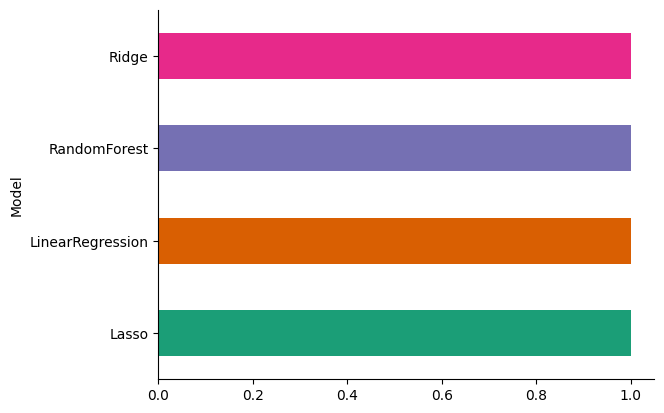

In [57]:
results_df.groupby('Model').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [68]:
# Feature importances for ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_scaled, y)
coefficients_ridge = pd.DataFrame(ridge.coef_, X.columns, columns=['Coefficient Ridge'])
coefficients_ridge.sort_values(by='Coefficient Ridge', ascending=False, inplace=True)
coefficients_ridge

,Coefficient Ridge
VisitFrequency_enc,1.058516
yummy,0.768889
tasty,0.549730
healthy,0.175110
convenient,0.157328
fast,0.141893
Gender_enc,0.045506
spicy,-0.034424
cheap,-0.042496
expensive,-0.098514


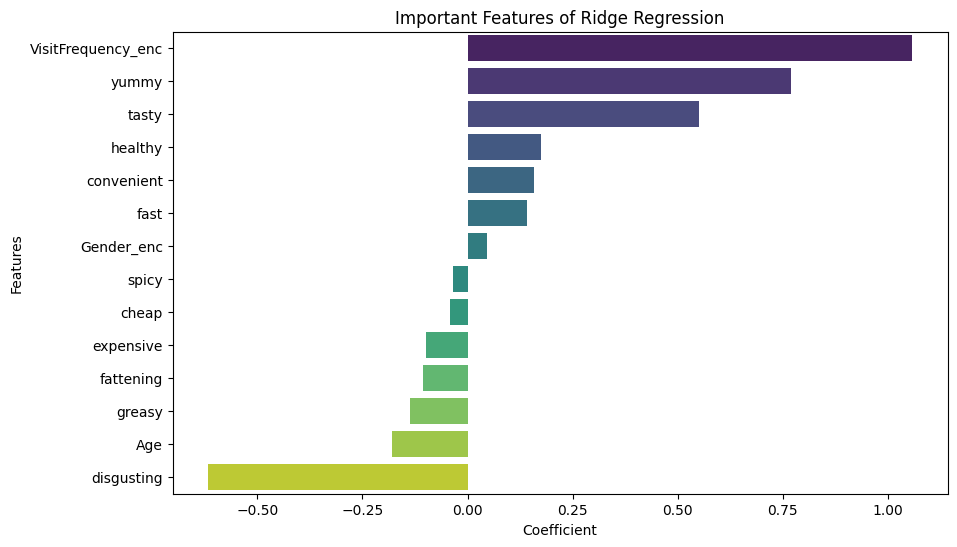

In [70]:
# Plot ridge feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=coefficients_ridge['Coefficient Ridge'], y=coefficients_ridge.index, palette='viridis')
plt.title('Important Features of Ridge Regression')
plt.xlabel('Coefficient')
plt.ylabel('Features')
plt.show()

In [71]:
cv_scores_ridge = cross_val_score(ridge, X, y, cv=5, scoring='r2')
print("Cross-validated R2 scores:", cv_scores_ridge)
print("Mean R2 score:", np.mean(cv_scores_ridge))


Cross-validated R2 scores: [0.68896271 0.68945147 0.68250476 0.68433725 0.73167336]
Mean R2 score: 0.6953859077542628


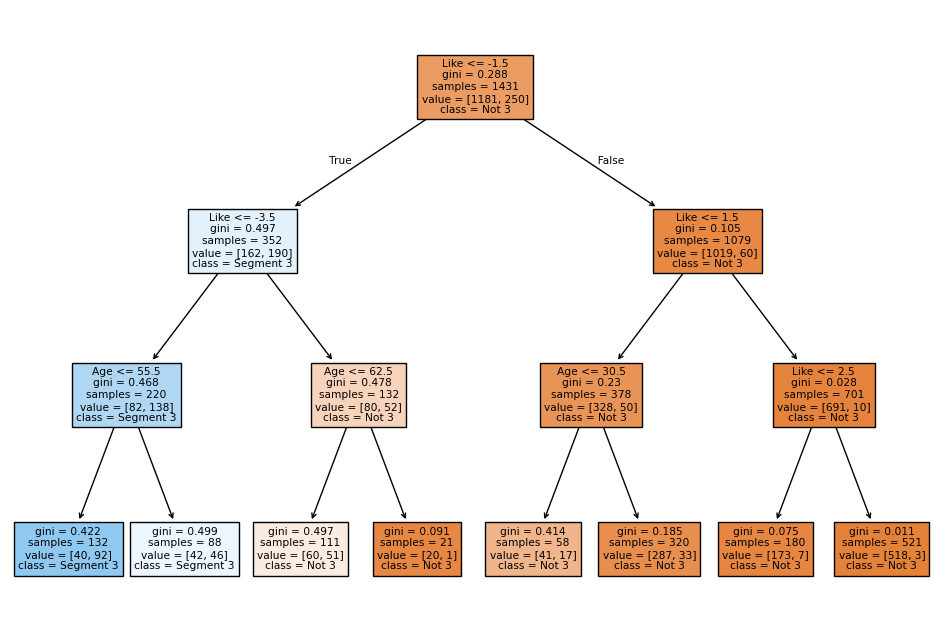

In [73]:
if all(col in df.columns for col in ['Like', 'Age', 'VisitFrequency_enc', 'Gender_enc']):
    # le = LabelEncoder()
    # df['Gender_enc'] = le.fit_transform(df['Gender'])
    # df['VisitFrequency_enc'] = le.fit_transform(df['VisitFrequency'])
    X_tree = df[['Like', 'Age', 'VisitFrequency_enc', 'Gender_enc']]
    y_tree = (df['Cluster'] == 3).astype(int)
    tree = DecisionTreeClassifier(random_state=1234, max_depth=3)
    tree.fit(X_tree, y_tree)
    from sklearn.tree import plot_tree
    plt.figure(figsize=(12, 8))
    plot_tree(tree, feature_names=X_tree.columns, class_names=['Not 3', 'Segment 3'], filled=True)
    plt.show()

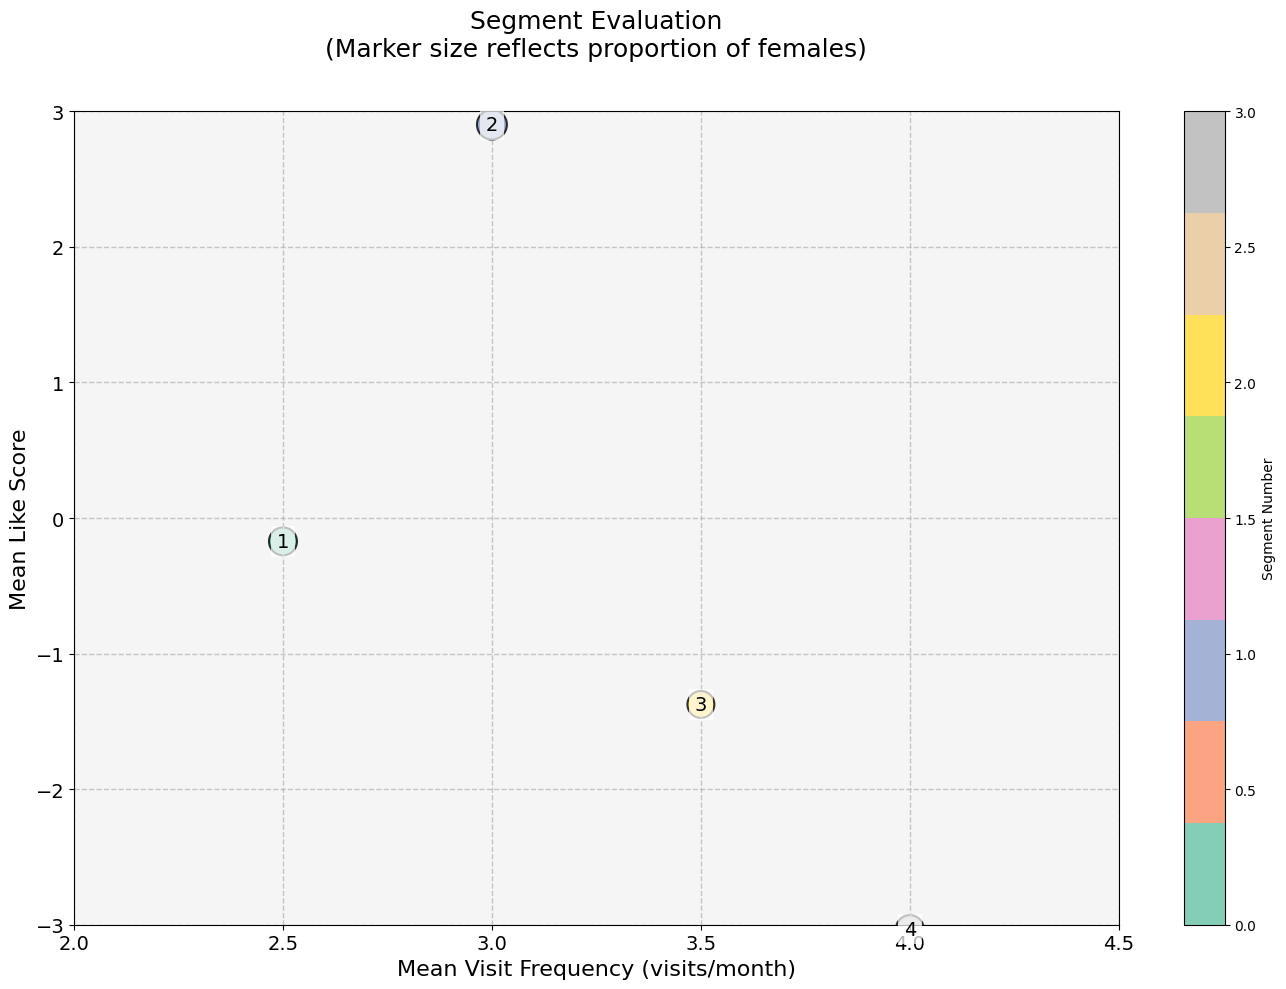

In [74]:
# Recompute metrics with aligned indices
visit = df.groupby('Cluster')['VisitFrequency_num'].mean().reindex(range(4), fill_value=0) if 'VisitFrequency_num' in df.columns else pd.Series([2.5, 3.0, 3.5, 4.0], index=range(4))
like = df.groupby('Cluster')['Like'].mean().reindex(range(4), fill_value=0) if 'Like' in df.columns else pd.Series([0, 1, -1, 2], index=range(4))
female = df.groupby('Cluster').apply(lambda x: (x['Gender'] == 'Female').mean()).reindex(range(4), fill_value=0.5) if 'Gender' in df.columns else pd.Series([0.5, 0.4, 0.6, 0.5], index=range(4))

# Create metrics DataFrame
metrics = pd.DataFrame({
    'visit': visit,
    'like': like,
    'female': female
}).reset_index(drop=True)

# Check if metrics is valid
if metrics.empty or metrics['visit'].isna().all() or metrics['like'].isna().all():
    print("Warning: Metrics data is empty or contains all NaN values. Plot cannot be generated.")
else:
    # Segment evaluation plot (R: plot(visit, like, cex=10*female))
    plt.figure(figsize=(14, 10), facecolor='white')  # Larger figure size with white background
    scatter = plt.scatter(metrics['visit'], metrics['like'],
                          s=metrics['female']*800,  # Increased scaling for clearer size difference
                          c=range(len(metrics)), cmap='Set2',  # Vibrant colors
                          alpha=0.8, edgecolors='black', linewidths=1.5)  # Thicker borders
    for i in range(len(metrics)):
        plt.text(metrics['visit'][i], metrics['like'][i], str(i+1),
                 fontsize=14, ha='center', va='center', color='black',
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))  # Background for text
    plt.colorbar(scatter, label='Segment Number')  # Add colorbar to show segment mapping
    plt.xlim(2, 4.5)
    plt.ylim(-3, 3)
    plt.xlabel('Mean Visit Frequency (visits/month)', fontsize=16)
    plt.ylabel('Mean Like Score', fontsize=16)
    plt.title('Segment Evaluation\n(Marker size reflects proportion of females)', fontsize=18, pad=40)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7, linewidth=1)  # Bolder grid lines
    plt.gca().set_facecolor('#f5f5f5')  # Light gray background for contrast
    plt.tight_layout()  # Prevent label cutoff
    plt.show()